Exersice 1 - Import the Global Life Expectancy Dataset

Each point of an exercice is represented in one cell !!!




In [3]:
#This part reads the dataset
import pandas as pd

gapminder_dataset = pd.read_csv("gapminder_dataset.csv")

In [4]:
#Display the first 5 rows of the dataset
gapminder_dataset.head()

,country,year,residents,continent,life_exp,gdp_cap
0,Afghanistan,1952.0,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957.0,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962.0,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967.0,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972.0,13079460.0,Asia,36.088,739.981106


In [5]:
#The shape of dataset
gapminder_dataset.shape


(1704, 6)

In [6]:

gapminder_dataset.isnull().sum()



country      1
year         7
residents    2
continent    1
life_exp     3
gdp_cap      5
dtype: int64

In [7]:
#new dataset without missing values
gapminder_cleared = gapminder_dataset.dropna()
gapminder_cleared


,country,year,residents,continent,life_exp,gdp_cap
0,Afghanistan,1952.0,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957.0,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962.0,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967.0,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972.0,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987.0,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992.0,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997.0,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002.0,11926563.0,Africa,39.989,672.038623


In [8]:
#check for missing values again -> no missing values after clearing
gapminder_cleared.isnull().sum()

country      0
year         0
residents    0
continent    0
life_exp     0
gdp_cap      0
dtype: int64

Exercise 2 - Random Sampling

In [9]:
#random 10% from dataset
gapminder_sample = gapminder_cleared.sample(frac = 0.1, random_state = 42)
gapminder_sample


,country,year,residents,continent,life_exp,gdp_cap
1216,Philippines,1972.0,40850141.0,Asia,58.065,1989.374070
1184,Panama,1992.0,2484997.0,Americas,72.462,6618.743050
578,Ghana,1962.0,7355248.0,Africa,46.452,1190.041118
50,Argentina,1962.0,21283783.0,Americas,65.142,7133.166023
1544,Togo,1992.0,3747553.0,Africa,58.061,1034.298904
...,...,...,...,...,...,...
74,Austria,1962.0,7129864.0,Europe,69.540,10750.721110
110,Belgium,1962.0,9218400.0,Europe,70.250,10991.206760
274,Chad,2002.0,8835739.0,Africa,50.525,1156.181860
496,Eritrea,1972.0,2260187.0,Africa,44.142,514.324208


In [10]:
#basic statistics of the sample
gapminder_sample.describe()

,year,residents,life_exp,gdp_cap
count,168.000000,1.680000e+02,168.000000,168.000000
mean,1980.869048,2.156379e+07,59.679958,8037.991814
std,17.082946,7.244811e+07,13.078036,11297.630882
min,1952.000000,6.001100e+04,33.489000,347.000000
25%,1967.000000,2.537198e+06,48.721750,1246.295553
50%,1982.000000,6.394268e+06,59.992500,4433.695004
75%,1997.000000,1.718260e+07,71.457500,10166.285412
max,2007.000000,8.620300e+08,81.235000,95458.111760


In [31]:
#total number of data entries in the sample
print(len(gapminder_sample))

#I assumed that each row is treated as one cell,
#which is also the entry so there are 168 rows in total,thus the number of total entries is 168 

168


Exercise 3 - Sampling with Replacement


In [12]:
#sample of 10 % with replacement
gapminder_sample_with_rep = gapminder_cleared.sample(frac = 0.1,random_state = 42, replace = True)
gapminder_sample_with_rep


,country,year,residents,continent,life_exp,gdp_cap
1144,Norway,1972.0,3933004.0,Europe,74.340,18965.055510
1478,Switzerland,1962.0,5666000.0,Europe,71.320,20431.092700
876,Lesotho,1952.0,748747.0,Africa,42.138,298.846212
1313,Saudi Arabia,1977.0,8128505.0,Asia,58.690,34167.762600
1148,Norway,1992.0,4286357.0,Europe,77.320,33965.661150
...,...,...,...,...,...,...
1503,Taiwan,1967.0,13648692.0,Asia,67.500,2643.858681
1617,United States,1997.0,272911760.0,Americas,76.810,35767.433030
879,Lesotho,1967.0,996380.0,Africa,48.492,498.639026
755,Ireland,2007.0,4109086.0,Europe,78.885,40675.996350


In [13]:
#basic statistics of this sample
gapminder_sample_with_rep.describe()



,year,residents,life_exp,gdp_cap
count,168.000000,1.680000e+02,168.000000,168.000000
mean,1979.232143,3.596581e+07,60.456763,8212.038374
std,17.558789,1.243779e+08,12.675707,12059.970162
min,1952.000000,8.989800e+04,32.500000,298.846212
25%,1965.750000,2.795314e+06,49.502750,1287.610862
50%,1977.000000,7.403310e+06,62.115000,3516.196408
75%,1997.000000,2.053276e+07,71.660500,10712.713518
max,2007.000000,1.280400e+09,81.757000,109347.867000


In [14]:
#total number of entries in this sample
print(gapminder_sample_with_rep.size)

1008


Exercise 4 - Visual Comparison of Random Sample vs Sample with Replacement

Text(0.5, 1.0, 'Distribution of Life Expectancy')

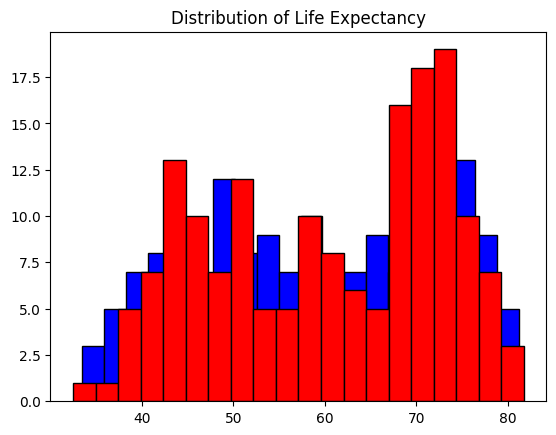

In [15]:
#visual comparison of life_exp both samples 
import matplotlib.pyplot as plot

plot.hist(gapminder_sample["life_exp"],bins = 20, color='blue',edgecolor="black")
plot.hist(gapminder_sample_with_rep["life_exp"],bins = 20, color = "red", edgecolor = "black")
plot.title("Distribution of Life Expectancy")


Exercise 5 - Compare the Mean Life Expectancy for Each Sampling Method



In [16]:
#mean of life_exp for both samples
print(gapminder_sample["life_exp"].mean())
print(gapminder_sample_with_rep["life_exp"].mean())

59.67995761904761
60.456762619047616


In [17]:
#comparing the results of life_exp for each sample
print("Mean of life_exp (NO replacement): ",gapminder_sample["life_exp"].mean())
print("Mean of life_exp (WITH replacement): ",gapminder_sample_with_rep["life_exp"].mean())

Mean of life_exp (NO replacement):  59.67995761904761
Mean of life_exp (WITH replacement):  60.456762619047616


Part 2 - Uncertainty Estimation

Exercise 6 - Calculate the Standard Error in the Mean(SEM) for Random Sample

In [18]:
#Calculating SEM for the random sample

import math
n = gapminder_sample.shape[0]                #size 168
STD = gapminder_sample["life_exp"].std()
SEM = STD / math.sqrt(n)
print(SEM)



1.0089924143243005


Exercise 7 - Calculate the Confidence Interval for Random Sample



In [19]:
%pip install scipy


Note: you may need to restart the kernel to use updated packages.


In [20]:
#calculating 95% interval range for the random sample
from scipy import stats

confidence_interval = stats.t.interval(confidence = 0.95,
                                       df = n-1,
                                       loc = gapminder_sample["life_exp"].mean(),
                                       scale = SEM)

print("The range of 95% confidence interval of the random sample is between"+" "+str(confidence_interval[0])+" "+"and"+" "+str(confidence_interval[1]))

The range of 95% confidence interval of the random sample is between 57.68793319958553 and 61.6719820385097


In [21]:
#calculating 95% interval range for the random sample with replacement
#STD_with_rep and SEM_with_rep they are STD and SEM for the random sample with replacement

n_for_rep = gapminder_sample_with_rep.shape[0]
STD_with_rep = gapminder_sample_with_rep["life_exp"].std()
SEM_with_rep = STD_with_rep / math.sqrt(n)

confidence_interval_with_rep = stats.t.interval(confidence = 0.95,
                                               df = n_for_rep - 1,
                                               loc = gapminder_sample_with_rep["life_exp"].mean(),
                                               scale = SEM_with_rep)

print("The range of 95% confidence interval of the random sample with replacement is between"+" "+str(confidence_interval_with_rep[0])+" "+"and"+" "+str(confidence_interval_with_rep[1]))


The range of 95% confidence interval of the random sample with replacement is between 58.52602033852462 and 62.387504899570615


Exercise 9 - Plot SEM as Error Bars

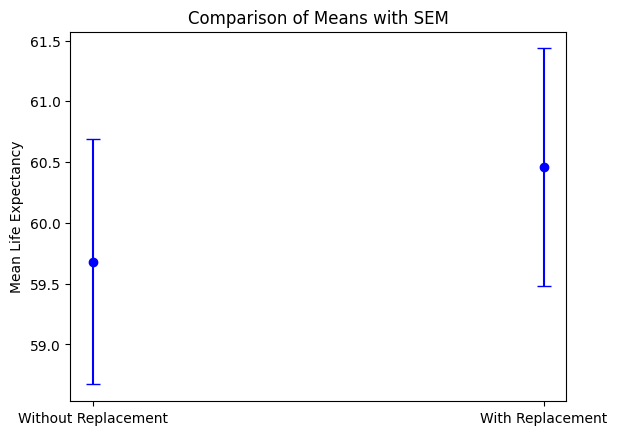

In [22]:
means = [gapminder_sample["life_exp"].mean(),gapminder_sample_with_rep["life_exp"].mean()]
sems = [SEM, SEM_with_rep]
labels = ['Without Replacement', 'With Replacement']
x_axis = [0, 1]  

plot.errorbar(x_axis, means, yerr=sems, fmt="o", capsize=5, color='blue')
plot.xticks(x_axis, labels)

plot.ylabel("Mean Life Expectancy")
plot.title("Comparison of Means with SEM")
plot.show()



Exercise 10 - Visualizing Sample and entire Dataset Values

In [23]:
#Working with 10%,20%,30%....100% samples of dataset and analyzing each of them.
#No replacement method
sample_1 = gapminder_cleared.sample(frac = 0.1, random_state = 1)
sample_2 = gapminder_cleared.sample(frac = 0.2, random_state = 1)
sample_3 = gapminder_cleared.sample(frac = 0.3, random_state = 1)
sample_4 = gapminder_cleared.sample(frac = 0.4, random_state = 1)
sample_5 = gapminder_cleared.sample(frac = 0.5, random_state = 1)
sample_6 = gapminder_cleared.sample(frac = 1.0, random_state = 1)



In [24]:
sample_2 = gapminder_cleared.sample(frac = 0.2, random_state =1)
sample_2_STD = sample_2["life_exp"].std()
sample_2_STD

np.float64(13.048803188318548)

In [25]:
#Calculating entire mean and entire std from the entire pre-processed dataset
entire_mean = gapminder_cleared["life_exp"].mean()
entire_std = gapminder_cleared["life_exp"].std()

In [26]:
#Computing the sample mean and SEM for each sample size

#calculating the sample mean for each sample
sample_1_mean = sample_1["life_exp"].mean()
sample_2_mean = sample_2["life_exp"].mean()
sample_3_mean = sample_3["life_exp"].mean()
sample_4_mean = sample_4["life_exp"].mean()
sample_5_mean = sample_5["life_exp"].mean()
sample_6_mean = sample_6["life_exp"].mean()

#calculating STD for each sample
sample_1_STD = sample_1["life_exp"].std()
sample_2_STD = sample_2["life_exp"].std()
sample_3_STD = sample_3["life_exp"].std()
sample_4_STD = sample_4["life_exp"].std()
sample_5_STD = sample_5["life_exp"].std()
sample_6_STD = sample_6["life_exp"].std()

#Finding each sample size n for each sample
sample_1_n = sample_1.shape[0]
sample_2_n = sample_2.shape[0]
sample_3_n = sample_3.shape[0]
sample_4_n = sample_4.shape[0]
sample_5_n = sample_5.shape[0]
sample_6_n = sample_6.shape[0]

#Calculating SEM for each sample
sample_1_SEM = sample_1_STD / math.sqrt(sample_1_n)
sample_2_SEM = sample_2_STD / math.sqrt(sample_2_n)
sample_3_SEM = sample_3_STD / math.sqrt(sample_3_n)
sample_4_SEM = sample_4_STD / math.sqrt(sample_4_n)
sample_5_SEM = sample_5_STD / math.sqrt(sample_5_n)
sample_6_SEM = sample_6_STD / math.sqrt(sample_6_n)


In [27]:
#STDs for each sample  
sample_1_STD = sample_1["life_exp"].std()
sample_2_STD = sample_2["life_exp"].std()
sample_3_STD = sample_3["life_exp"].std()
sample_4_STD = sample_4["life_exp"].std()
sample_5_STD = sample_5["life_exp"].std()
sample_6_STD = sample_6["life_exp"].std()

sample_1_conf_interval = stats.t.interval(confidence = 0.95,
                                          df = sample_1_n - 1,
                                          loc = sample_1_mean,
                                          scale = sample_1_SEM)

sample_2_conf_interval = stats.t.interval(confidence = 0.95,
                                          df = sample_2_n - 1,
                                          loc = sample_2_mean,
                                          scale = sample_2_SEM)

sample_3_conf_interval = stats.t.interval(confidence = 0.95,
                                          df = sample_3_n - 1,
                                          loc = sample_3_mean,
                                          scale = sample_3_SEM)

sample_4_conf_interval = stats.t.interval(confidence = 0.95,
                                          df = sample_4_n - 1,
                                          loc = sample_4_mean,
                                          scale = sample_4_SEM)

sample_5_conf_interval = stats.t.interval(confidence = 0.95,
                                          df = sample_5_n - 1,
                                          loc = sample_5_mean,
                                          scale = sample_5_SEM)
                                          

sample_6_conf_interval = stats.t.interval(confidence = 0.95,
                                          df = sample_6_n - 1,
                                          loc = sample_6_mean,
                                          scale = sample_6_SEM)
                                          

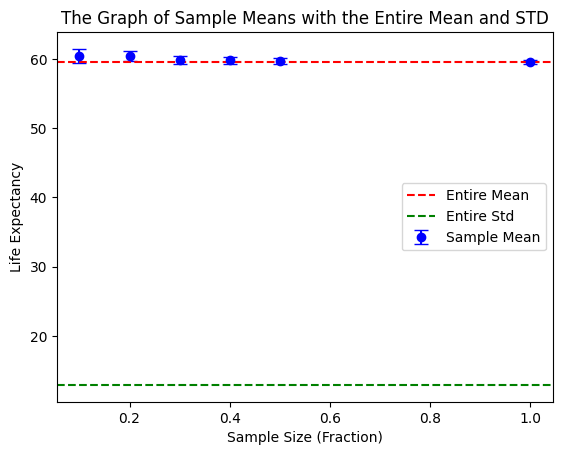

In [28]:
#Ploting sample means and confidence intervals(as error bars)

mean_values = [sample_1_mean, sample_2_mean,sample_3_mean,sample_4_mean,sample_5_mean,sample_6_mean]
confidence_intervals = [sample_1_conf_interval,sample_2_conf_interval,sample_3_conf_interval,sample_4_conf_interval,sample_5_conf_interval,sample_6_conf_interval]
fractions = [0.1,0.2,0.3,0.4,0.5,1.0]
sems = [sample_1_SEM,sample_2_SEM,sample_3_SEM,sample_4_SEM,sample_5_SEM,sample_6_SEM]
stds = [sample_1_STD,sample_2_STD,sample_3_STD,sample_4_STD,sample_5_STD,sample_6_STD]


plot.errorbar(fractions, mean_values, yerr=sems, fmt='o', capsize=5,color='blue', label='Sample Mean')
plot.axhline(y=entire_mean, color='red', linestyle='--', label='Entire Mean')
plot.axhline(y=entire_std, color='green', linestyle='--', label='Entire Std')
plot.xlabel("Sample Size (Fraction)")
plot.ylabel("Life Expectancy")
plot.title("The Graph of Sample Means with the Entire Mean and STD")
plot.legend()
plot.show()


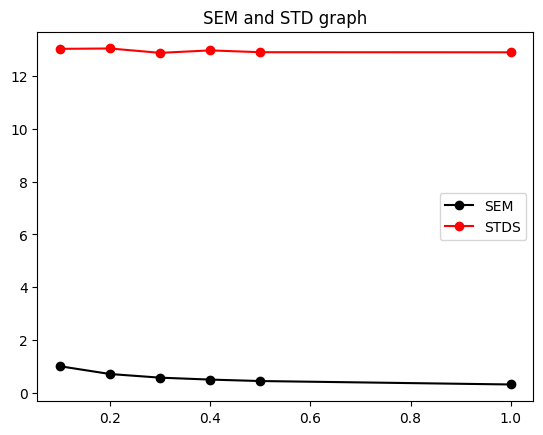

In [29]:
#Plotting SEM and sample standard deviation

plot.plot(fractions,sems,marker="o", color="black",label="SEM")
plot.plot(fractions,stds,marker="o", color="red",label="STDS")
plot.legend()
plot.title("SEM and STD graph")
plot.show()
